In [1]:
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import sys
import os

sys.path.append('../')
from utils.compute_metrics import compute_rmse

In [2]:
def plot_comparison(svd_actuals, svd_preds, pmf_actuals, pmf_preds, svd_rmse, pmf_rmse, reports_dir='./reports'):
    os.makedirs(reports_dir, exist_ok=True)
    
    # predicted vs actual
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(svd_actuals, svd_preds, alpha=0.3, s=1, color='blue')
    axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2)
    axes[0].set_xlabel('Actual Rating')
    axes[0].set_ylabel('Predicted Rating')
    axes[0].set_title(f'SVD — RMSE={round(svd_rmse, 4)}')
    axes[1].scatter(pmf_actuals, pmf_preds, alpha=0.3, s=1, color='green')
    axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2)
    axes[1].set_xlabel('Actual Rating')
    axes[1].set_ylabel('Predicted Rating')
    axes[1].set_title(f'PMF — RMSE={round(pmf_rmse, 4)}')
    plt.tight_layout()
    plt.savefig(f'{reports_dir}/predicted_vs_actual.png')
    plt.close()
    print("Saved predicted_vs_actual.png")

    # RMSE bar chart
    plt.figure(figsize=(6, 5))
    bars = plt.bar(['SVD', 'PMF'], [svd_rmse, pmf_rmse], color=['#ff6b6b', '#51cf66'], width=0.4)
    plt.axhline(y=0.90, color='red',   linestyle='--', label='SVD target (0.90)')
    plt.axhline(y=0.85, color='green', linestyle='--', label='PMF target (0.85)')
    for bar, val in zip(bars, [svd_rmse, pmf_rmse]):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11)
    plt.ylabel('RMSE')
    plt.title('SVD vs PMF RMSE Comparison')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{reports_dir}/rmse_comparison.png')
    plt.close()
    print("Saved rmse_comparison.png")

In [3]:
#load data
try:
    svd_predicted = np.load('./reports/svd_predictions.npy')
    pmf_predicted = np.load('./reports/pmf_predictions.npy')
    
    test_data = pd.read_csv('./processed/test_data.csv')
    train_data = pd.read_csv('./processed/train_data.csv')
    
    user_index  = joblib.load('./processed/user_index.pkl')
    movie_index = joblib.load('./processed/movie_index.pkl')
    
    movies_pd = pd.read_csv('./data/movies.dat', sep='::', encoding='latin-1', engine='python', names=["MovieID","Title","Genres"])
    ratings_pd = pd.read_csv('./data/ratings.dat', sep='::', encoding='latin-1',engine='python',names=["UserID","MovieID","Rating","Timestamp"])
except Exception as e:
    print(f"Failed to load data: {e}")

## Key Insights

- **Ratings skew positive** — most users rate 4s and 5s, very few give 1s
- **Power users dominate** — top 10 users each rated 1300+ movies
- **Drama and Comedy** are the most common genres by volume
- **Film-Noir and Documentary** have the highest avg ratings despite low volume
- **Matrix sparsity ~95%+** — justifies matrix factorization over simple methods
- Most users rate fewer than 200 movies, making personalization hard without latent factors

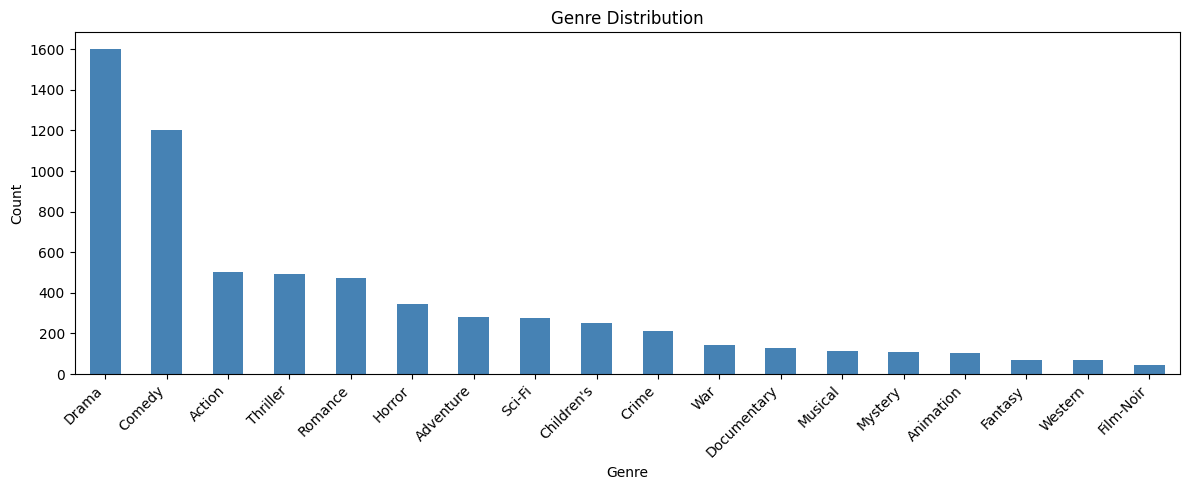

C:\Users\salma\AppData\Local\Temp\ipykernel_16732\1466032920.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train_data.set_index('Timestamp')['Rating'].resample('M').mean().plot(


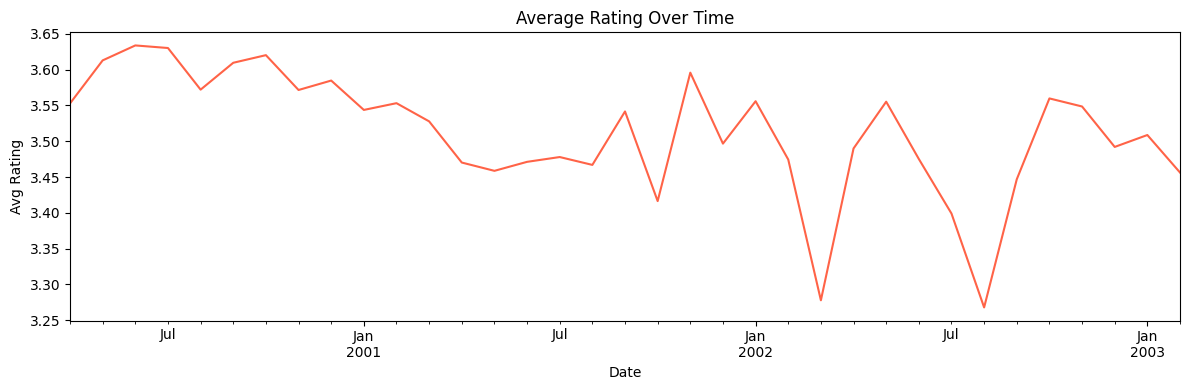

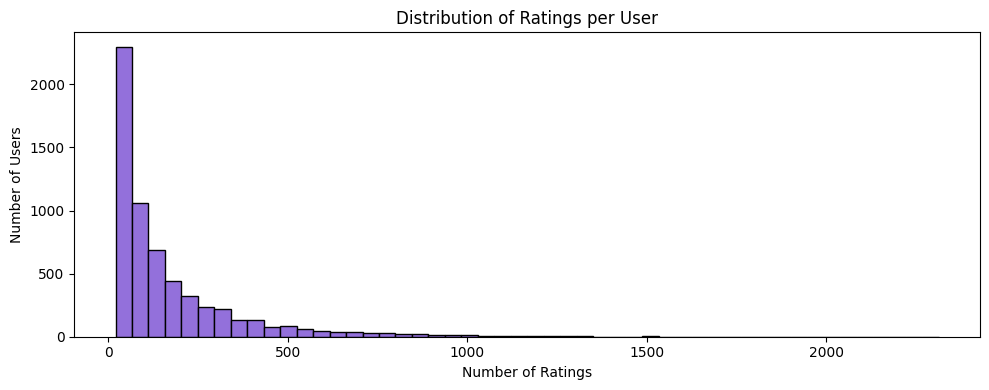

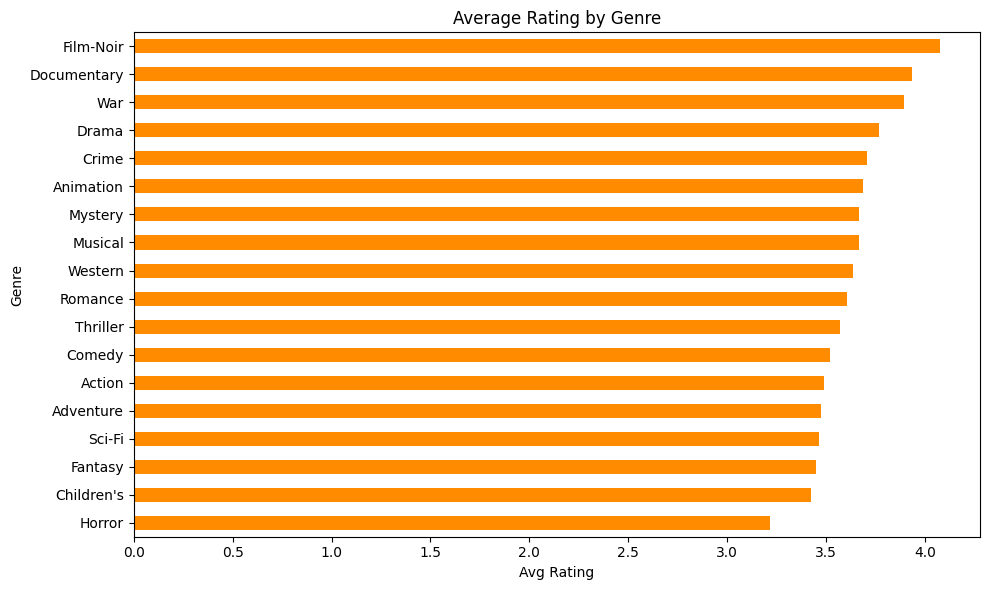

Users:    6040
Movies:   3706
Ratings:  1,000,209
Sparsity: 95.53%


In [4]:
# Genre distribution
movies_pd['Genres'].str.split('|').explode().value_counts().plot(
    kind='bar', title='Genre Distribution', color='steelblue', figsize=(12,5))
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

train_data['Timestamp'] = pd.to_datetime(train_data['Timestamp'], unit='s')
train_data.set_index('Timestamp')['Rating'].resample('M').mean().plot(
    title='Average Rating Over Time', figsize=(12,4), color='tomato')
plt.ylabel('Avg Rating')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

user_activity = ratings_pd.groupby('UserID')['Rating'].count()
user_activity.plot(kind='hist', bins=50, title='Distribution of Ratings per User',
                   color='mediumpurple', figsize=(10,4), edgecolor='black')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

exploded = movies_pd.assign(Genre=movies_pd['Genres'].str.split('|')).explode('Genre')
merged = ratings_pd.merge(exploded[['MovieID','Genre']], on='MovieID')
merged.groupby('Genre')['Rating'].mean().sort_values().plot(
    kind='barh', title='Average Rating by Genre', color='darkorange', figsize=(10,6))
plt.xlabel('Avg Rating')
plt.tight_layout()
plt.show()

total_cells = ratings_pd['UserID'].nunique() * ratings_pd['MovieID'].nunique()
filled_cells = len(ratings_pd)
sparsity = 1 - (filled_cells / total_cells)
print(f"Users:    {ratings_pd['UserID'].nunique()}")
print(f"Movies:   {ratings_pd['MovieID'].nunique()}")
print(f"Ratings:  {filled_cells:,}")
print(f"Sparsity: {sparsity:.2%}")

In [5]:
#evaluate models based on rmse
svd_rmse, svd_actuals, svd_preds = compute_rmse(test_data, svd_predicted, user_index, movie_index)
pmf_rmse, pmf_actuals, pmf_preds = compute_rmse(test_data, pmf_predicted, user_index, movie_index)

improvement = round((svd_rmse - pmf_rmse) / svd_rmse * 100, 0)

print(f"SVD RMSE:    {svd_rmse:.4f}")
print(f"PMF RMSE:    {pmf_rmse:.4f}")
print(f"Improvement: {improvement}%")

SVD RMSE:    0.8899
PMF RMSE:    0.8462
Improvement: 5.0%


In [6]:
#save metrics

metrics = {
    "SVD_RMSE": round(svd_rmse, 4),
    "PMF_RMSE": round(pmf_rmse, 4),
    "PMF_vs_SVD_improvement_%": improvement
}
with open('./reports/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

In [7]:
#plot and save the findings

plot_comparison(svd_actuals, svd_preds, pmf_actuals, pmf_preds, svd_rmse, pmf_rmse)

Saved predicted_vs_actual.png
Saved rmse_comparison.png
